In [1]:
train_dir = r"C:\users\Apex-pc\Downloads\archive (1)"

In [2]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [3]:
train_datagen =ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=(150,150),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

val_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=(150,150),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)

Found 8450 images belonging to 4 classes.
Found 2110 images belonging to 4 classes.


In [4]:
import tensorflow as tf

model = tf.keras.models.Sequential([
    tf.keras.Input(shape=(150,150, 3)),

    tf.keras.layers.Conv2D(32, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2, 2),

    tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2, 2),

    tf.keras.layers.Conv2D(128, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2, 2),

    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.5),

    tf.keras.layers.Dense(4, activation='softmax')
])

In [5]:
model.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['categorical_accuracy']
)

In [6]:
history = model.fit(
    train_data,
    epochs=10,
    validation_data=val_data,
)

Epoch 1/10
265/265 ━━━━━━━━━━━━━━━━━━━━ 220s 822ms/step - categorical_accuracy: 0.6931 - loss: 0.7371 - val_categorical_accuracy: 0.8147 - val_loss: 0.5133
Epoch 2/10
265/265 ━━━━━━━━━━━━━━━━━━━━ 121s 457ms/step - categorical_accuracy: 0.8353 - loss: 0.4237 - val_categorical_accuracy: 0.8763 - val_loss: 0.3161
Epoch 3/10
265/265 ━━━━━━━━━━━━━━━━━━━━ 132s 497ms/step - categorical_accuracy: 0.8761 - loss: 0.3171 - val_categorical_accuracy: 0.8829 - val_loss: 0.2959
Epoch 4/10
265/265 ━━━━━━━━━━━━━━━━━━━━ 141s 533ms/step - categorical_accuracy: 0.9013 - loss: 0.2591 - val_categorical_accuracy: 0.9232 - val_loss: 0.1931
Epoch 5/10
265/265 ━━━━━━━━━━━━━━━━━━━━ 140s 526ms/step - categorical_accuracy: 0.9253 - loss: 0.1980 - val_categorical_accuracy: 0.9265 - val_loss: 0.1966
Epoch 6/10
265/265 ━━━━━━━━━━━━━━━━━━━━ 113s 426ms/step - categorical_accuracy: 0.9392 - loss: 0.1560 - val_categorical_accuracy: 0.9318 - val_loss: 0.1854
Epoch 7/10
265/265 ━━━━━━━━━━━━━━━━━━━━ 119s 448ms/step - catego

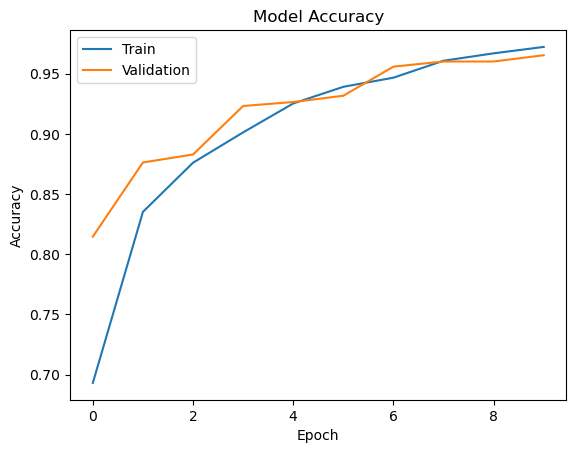

In [8]:
import matplotlib.pyplot as plt

plt.plot(history.history['categorical_accuracy'])
plt.plot(history.history['val_categorical_accuracy'])

plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'])

plt.show()